<a href="https://colab.research.google.com/github/goitstudent123/DL4CV-NLP/blob/main/dz_topic_4_HAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Етап 1. Імпорт необхідних бібліотек
!pip -q install kagglehub torch scikit-learn pandas matplotlib

import os
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from IPython.display import display

SEED = 42
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
# Етап 2. Завантаження набору даних з Kaggle

# Option A: read token from Colab Secret named KAGGLE_API_TOKEN
token = None
try:
    from google.colab import userdata
    token = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    pass

# Option B: paste token here only if you are not using Colab Secrets
if not token:
    token = "xxx"

if not token:
    raise ValueError(
        "Kaggle token was not found. Add KAGGLE_API_TOKEN to Colab Secrets or paste it into this block."
    )

os.environ["KAGGLE_API_TOKEN"] = token

import kagglehub

dataset_dir = Path(kagglehub.dataset_download("mchilamwar/predict-concrete-strength"))
csv_files = sorted(dataset_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files were found in: {dataset_dir}")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("Dataset directory:", dataset_dir)
print("CSV file:", csv_path.name)
print("Shape:", df.shape)

display(df.head())

100%|██████████| 11.1k/11.1k [00:00<00:00, 16.2MB/s]

Extracting files...
Dataset directory: /root/.cache/kagglehub/datasets/mchilamwar/predict-concrete-strength/versions/1
CSV file: ConcreteStrengthData.csv
Shape: (1030, 9)


,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


Original columns:
['cementcomponent', 'blastfurnaceslag', 'flyashcomponent', 'watercomponent', 'superplasticizercomponent', 'coarseaggregatecomponent', 'fineaggregatecomponent', 'ageindays', 'strength']

Clean columns:
['cementcomponent', 'blastfurnaceslag', 'flyashcomponent', 'watercomponent', 'superplasticizercomponent', 'coarseaggregatecomponent', 'fineaggregatecomponent', 'ageindays', 'strength']

Data types:
cementcomponent              float64
blastfurnaceslag             float64
flyashcomponent              float64
watercomponent               float64
superplasticizercomponent    float64
coarseaggregatecomponent     float64
fineaggregatecomponent       float64
ageindays                      int64
strength                     float64
dtype: object

Missing values:
cementcomponent              0
blastfurnaceslag             0
flyashcomponent              0
watercomponent               0
superplasticizercomponent    0
coarseaggregatecomponent     0
fineaggregatecomponent       0
ag

,count,mean,std,min,25%,50%,75%,max
cementcomponent,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
blastfurnaceslag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
flyashcomponent,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
watercomponent,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
superplasticizercomponent,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
coarseaggregatecomponent,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
fineaggregatecomponent,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
ageindays,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6



Detected target column: strength


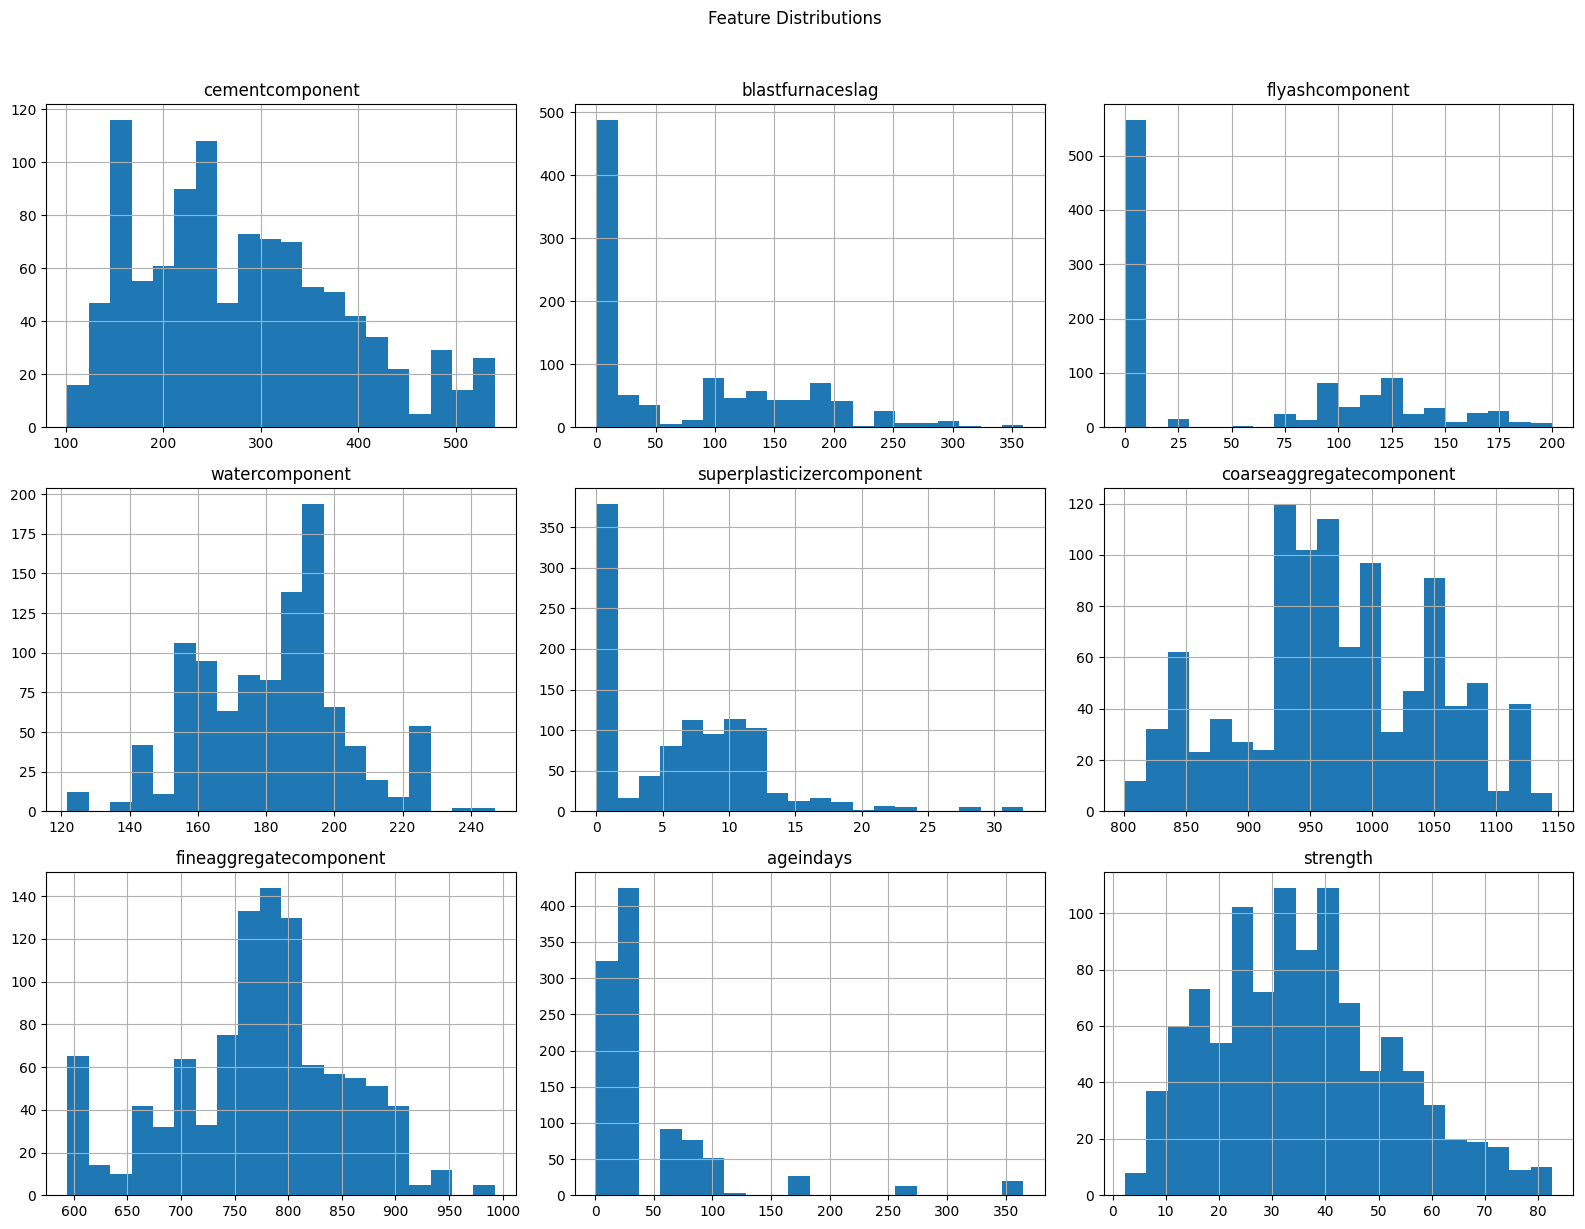

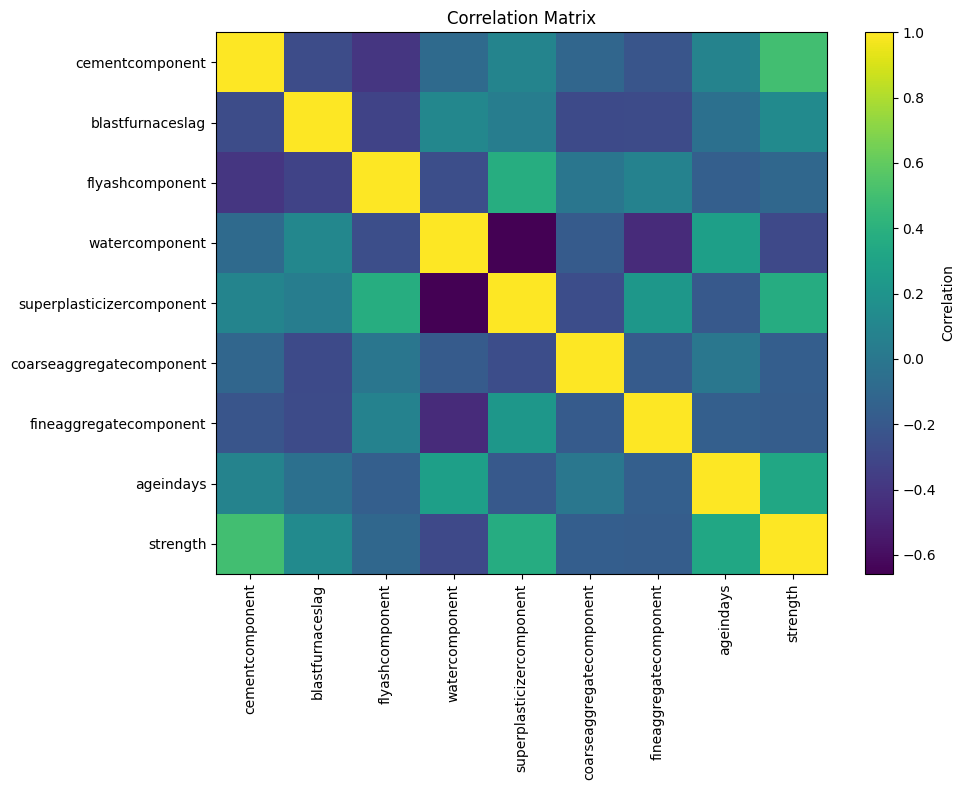

Correlations with target:


,correlation_with_target
strength,1.000000
cementcomponent,0.497832
superplasticizercomponent,0.366079
ageindays,0.328873
watercomponent,-0.289633
fineaggregatecomponent,-0.167241
coarseaggregatecomponent,-0.164935
blastfurnaceslag,0.134829
flyashcomponent,-0.105755


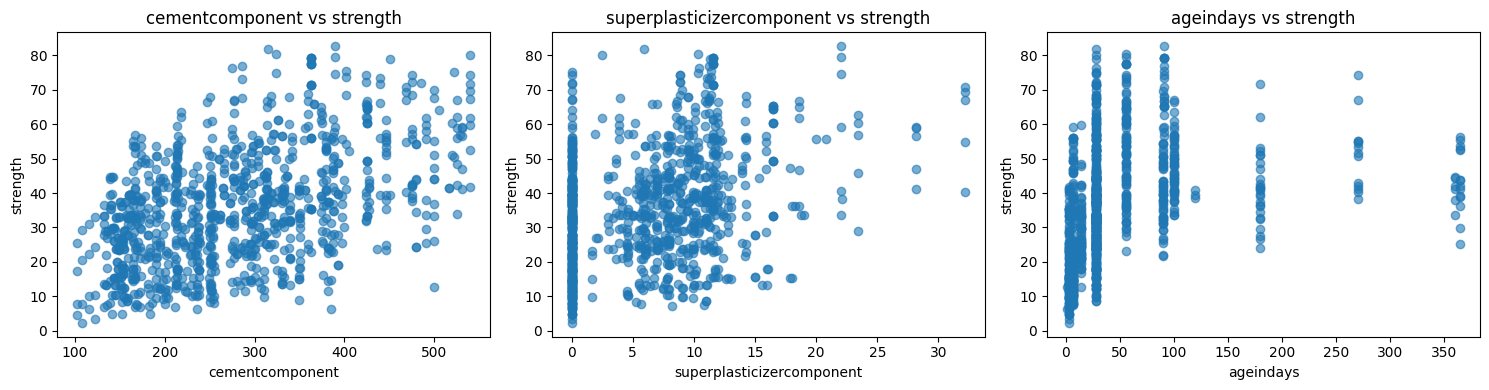


Age analysis:
Age skewness: 3.2692
log1p(Age) skewness: -0.0051


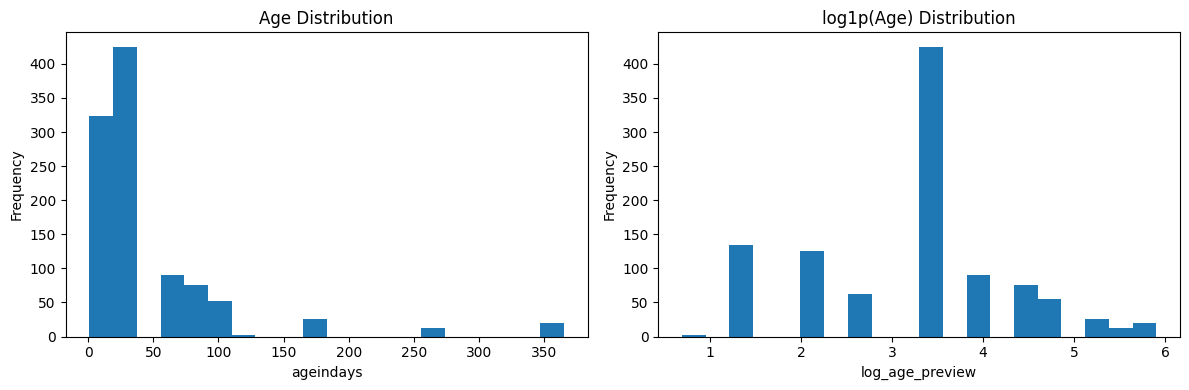

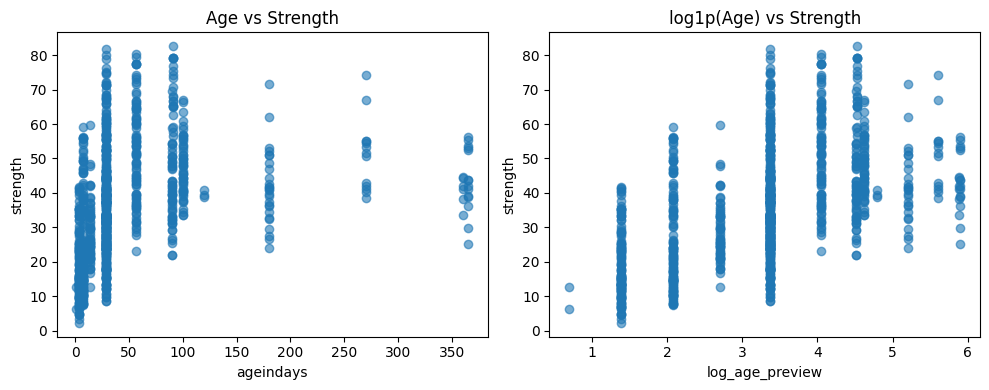

In [12]:
# Етап 3. Попередній аналіз даних

original_columns = df.columns.tolist()

# Clean column names for easier handling
df.columns = (
    df.columns.str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "", regex=True)
    .str.lower()
)

print("Original columns:")
print(original_columns)

print("\nClean columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

# Detect target column
target_candidates = [c for c in df.columns if "strength" in c or "compressive" in c]
target_col = target_candidates[0] if target_candidates else df.columns[-1]

print(f"\nDetected target column: {target_col}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Histograms
df[numeric_cols].hist(figsize=(16, 12), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Correlation matrix
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr[target_col].sort_values(key=lambda s: s.abs(), ascending=False)
print("Correlations with target:")
display(target_corr.to_frame(name="correlation_with_target"))

top_features = target_corr.drop(target_col).abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, len(top_features), figsize=(5 * len(top_features), 4))
if len(top_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, top_features):
    ax.scatter(df[feature], df[target_col], alpha=0.6)
    ax.set_xlabel(feature)
    ax.set_ylabel(target_col)
    ax.set_title(f"{feature} vs {target_col}")

plt.tight_layout()
plt.show()

# Additional analysis for age transformation
if "ageindays" in df.columns:
    df["log_age_preview"] = np.log1p(df["ageindays"])

    print("\nAge analysis:")
    print(f"Age skewness: {df['ageindays'].skew():.4f}")
    print(f"log1p(Age) skewness: {df['log_age_preview'].skew():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df["ageindays"], bins=20)
    axes[0].set_title("Age Distribution")
    axes[0].set_xlabel("ageindays")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(df["log_age_preview"], bins=20)
    axes[1].set_title("log1p(Age) Distribution")
    axes[1].set_xlabel("log_age_preview")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.scatter(df["ageindays"], df[target_col], alpha=0.6)
    plt.xlabel("ageindays")
    plt.ylabel(target_col)
    plt.title("Age vs Strength")

    plt.subplot(1, 2, 2)
    plt.scatter(df["log_age_preview"], df[target_col], alpha=0.6)
    plt.xlabel("log_age_preview")
    plt.ylabel(target_col)
    plt.title("log1p(Age) vs Strength")

    plt.tight_layout()
    plt.show()

    # Remove preview column to avoid accidental leakage into later steps
    df = df.drop(columns=["log_age_preview"])

In [13]:
# Етап 4. Підготовка даних

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Feature engineering based on concrete domain knowledge
if {"watercomponent", "cementcomponent"}.issubset(X.columns):
    X["water_cement_ratio"] = X["watercomponent"] / (X["cementcomponent"] + 1e-6)

if {"cementcomponent", "blastfurnaceslag", "flyashcomponent"}.issubset(X.columns):
    X["binder_total"] = (
        X["cementcomponent"] +
        X["blastfurnaceslag"] +
        X["flyashcomponent"]
    )
    X["water_binder_ratio"] = X["watercomponent"] / (X["binder_total"] + 1e-6)

if {"superplasticizercomponent", "cementcomponent", "blastfurnaceslag", "flyashcomponent"}.issubset(X.columns):
    if "binder_total" not in X.columns:
        X["binder_total"] = (
            X["cementcomponent"] +
            X["blastfurnaceslag"] +
            X["flyashcomponent"]
        )
    X["superplasticizer_binder_ratio"] = X["superplasticizercomponent"] / (X["binder_total"] + 1e-6)

if {"coarseaggregatecomponent", "fineaggregatecomponent"}.issubset(X.columns):
    X["coarse_fine_ratio"] = X["coarseaggregatecomponent"] / (X["fineaggregatecomponent"] + 1e-6)

if "ageindays" in X.columns:
    X["log_age"] = np.log1p(X["ageindays"])

# Encode categorical columns if they exist
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if categorical_cols:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert to numeric and handle missing values if needed
X = X.apply(pd.to_numeric, errors="coerce")
if X.isna().sum().sum() > 0:
    X = X.fillna(X.median(numeric_only=True))

feature_names = X.columns.tolist()

print("Engineered features added:")
engineered_features = [
    col for col in [
        "water_cement_ratio",
        "binder_total",
        "water_binder_ratio",
        "superplasticizer_binder_ratio",
        "coarse_fine_ratio",
        "log_age",
    ]
    if col in X.columns
]
print(engineered_features if engineered_features else "None")

# Train / validation / test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=SEED
)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

# DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("X shape after preprocessing:", X.shape)
print("Number of features:", len(feature_names))
print("Train set:", X_train_tensor.shape, y_train_tensor.shape)
print("Validation set:", X_val_tensor.shape, y_val_tensor.shape)
print("Test set:", X_test_tensor.shape, y_test_tensor.shape)
print("Categorical columns found:", categorical_cols if categorical_cols else "None")

# Quick correlation check after feature engineering
feature_target_corr = pd.concat([X, y.rename(target_col)], axis=1).corr(numeric_only=True)[target_col]
feature_target_corr = feature_target_corr.drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)

print("\nTop correlations with target after feature engineering:")
display(feature_target_corr.head(12).to_frame(name="correlation_with_target"))

Engineered features added:
['water_cement_ratio', 'binder_total', 'water_binder_ratio', 'superplasticizer_binder_ratio', 'coarse_fine_ratio', 'log_age']
X shape after preprocessing: (1030, 14)
Number of features: 14
Train set: torch.Size([659, 14]) torch.Size([659, 1])
Validation set: torch.Size([165, 14]) torch.Size([165, 1])
Test set: torch.Size([206, 14]) torch.Size([206, 1])
Categorical columns found: None

Top correlations with target after feature engineering:


,correlation_with_target
water_binder_ratio,-0.623087
binder_total,0.613184
log_age,0.549446
water_cement_ratio,-0.500692
cementcomponent,0.497832
superplasticizercomponent,0.366079
ageindays,0.328873
watercomponent,-0.289633
superplasticizer_binder_ratio,0.237994
fineaggregatecomponent,-0.167241


In [14]:
# Етап 5. Створення моделі нейронної мережі

class ConcreteStrengthRegressor(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

model = ConcreteStrengthRegressor(input_dim=X_train_tensor.shape[1]).to(device)
print(model)

ConcreteStrengthRegressor(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [15]:
# Етап 6. Налаштування навчання

# MSELoss is a natural choice for regression because the target is continuous.
# It is differentiable and penalizes large errors more strongly.

LEARNING_RATE = 1e-3
NUM_EPOCHS = 300
PATIENCE = 40

criterion = nn.MSELoss()

# Adam is used here because it usually converges faster and more stably
# than plain SGD on normalized tabular data.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")

Learning rate: 0.001
Batch size: 32
Epochs: 300
Early stopping patience: 40
Loss function: MSELoss
Optimizer: Adam


In [16]:
# Етап 7. Навчання моделі

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    batch_train_losses = []

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        batch_train_losses.append(loss.item())

    train_loss = float(np.mean(batch_train_losses))

    model.eval()
    batch_val_losses = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            batch_val_losses.append(loss.item())

    val_loss = float(np.mean(batch_val_losses))

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 001/300 | Train Loss: 1555.0492 | Val Loss: 1371.0782
Epoch 020/300 | Train Loss: 92.6555 | Val Loss: 63.3797
Epoch 040/300 | Train Loss: 57.3322 | Val Loss: 27.8571
Epoch 060/300 | Train Loss: 47.5799 | Val Loss: 20.8228
Epoch 080/300 | Train Loss: 37.9154 | Val Loss: 21.4530
Epoch 100/300 | Train Loss: 38.1082 | Val Loss: 18.7355
Epoch 120/300 | Train Loss: 37.2039 | Val Loss: 19.5140
Epoch 140/300 | Train Loss: 34.5056 | Val Loss: 19.6546
Epoch 160/300 | Train Loss: 36.8753 | Val Loss: 18.6110
Epoch 180/300 | Train Loss: 31.2505 | Val Loss: 17.2490
Early stopping triggered at epoch 185.
Best validation loss: 16.4086


In [17]:
# Етап 8. Оцінка моделі

def predict_numpy(model: nn.Module, X_array: np.ndarray, batch_size: int = 256) -> np.ndarray:
    model.eval()
    preds = []

    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (batch_X,) in loader:
            batch_X = batch_X.to(device)
            batch_preds = model(batch_X).cpu().numpy().reshape(-1)
            preds.append(batch_preds)

    return np.concatenate(preds)

y_val_pred = predict_numpy(model, X_val_scaled)
y_test_pred = predict_numpy(model, X_test_scaled)

val_mse = mean_squared_error(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Validation metrics:")
print(f"MSE: {val_mse:.4f}")
print(f"MAE: {val_mae:.4f}")
print(f"R² : {val_r2:.4f}")

print("\nTest metrics:")
print(f"MSE: {test_mse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R² : {test_r2:.4f}")

def quality_comment(mse, mae, r2):
    mse_level = (
        "excellent" if mse < 35 else
        "good" if mse < 55 else
        "acceptable" if mse <= 75 else
        "weak"
    )

    mae_level = (
        "excellent" if mae < 5 else
        "good" if mae < 8 else
        "acceptable" if mae <= 10 else
        "weak"
    )

    r2_level = (
        "excellent" if r2 > 0.8 else
        "good" if r2 > 0.7 else
        "acceptable" if r2 >= 0.6 else
        "weak"
    )

    return mse_level, mae_level, r2_level

mse_level, mae_level, r2_level = quality_comment(test_mse, test_mae, test_r2)

print("\nInterpretation against expected ranges:")
print(f"MSE quality: {mse_level}")
print(f"MAE quality: {mae_level}")
print(f"R² quality : {r2_level}")

Validation metrics:
MSE: 18.8473
MAE: 3.2287
R² : 0.9329

Test metrics:
MSE: 30.9625
MAE: 4.1199
R² : 0.8798

Interpretation against expected ranges:
MSE quality: excellent
MAE quality: excellent
R² quality : excellent


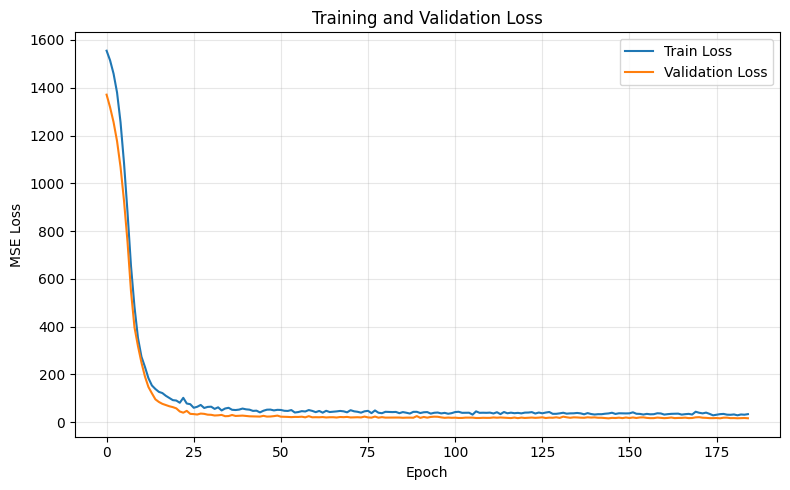

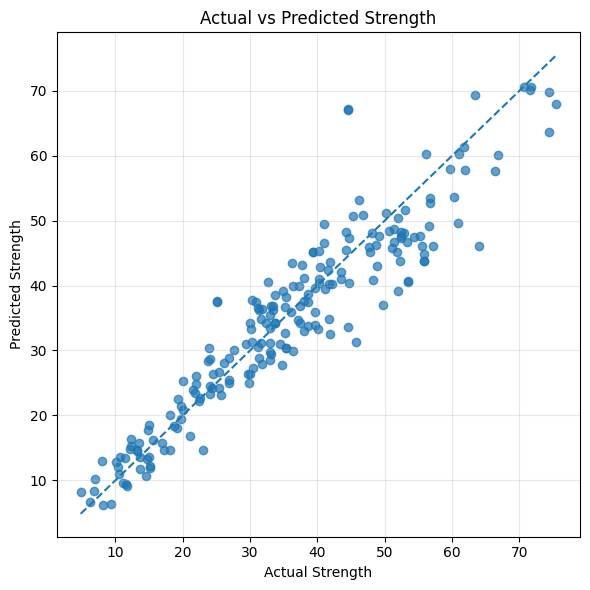

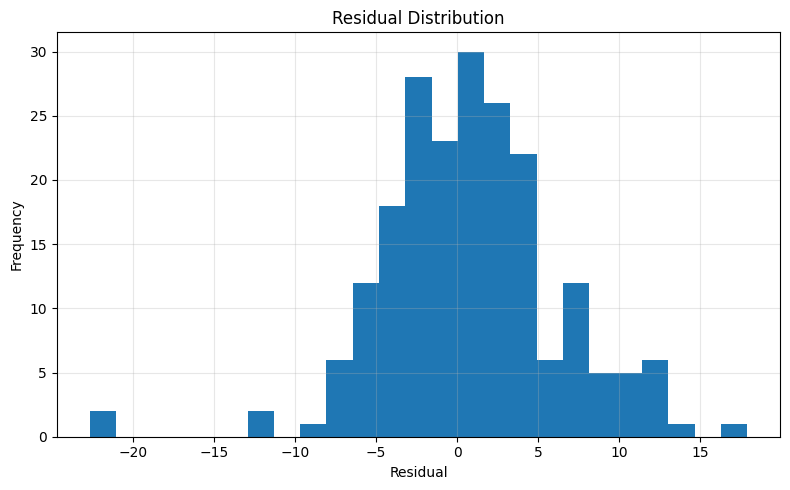

In [18]:
# Етап 9. Візуалізація результатів

# Loss curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted Strength")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test.values - y_test_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Permutation importance (higher MSE increase = more important feature):


,feature,mse_increase
13,log_age,169.199271
9,binder_total,74.365492
5,coarseaggregatecomponent,31.730944
3,watercomponent,29.363851
4,superplasticizercomponent,25.861026
0,cementcomponent,22.897760
10,water_binder_ratio,22.066191
12,coarse_fine_ratio,20.069563
2,flyashcomponent,17.511186
1,blastfurnaceslag,12.901020


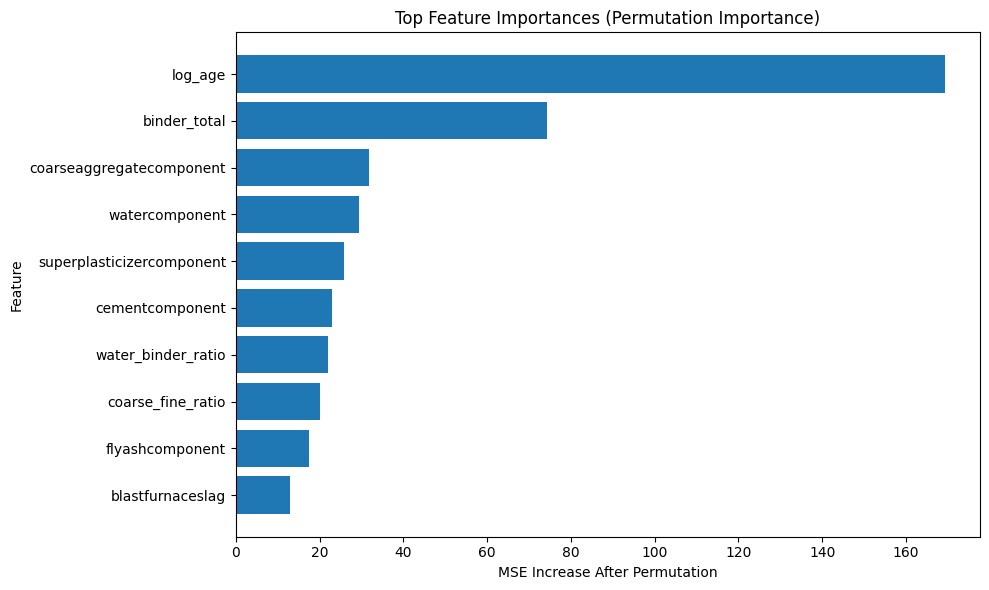

Conclusions:
1. The model achieved Test MSE = 30.96, MAE = 4.12, R² = 0.880.
2. The metrics should be compared with the expected ranges from the assignment.
3. The most influential features according to permutation importance are: log_age, binder_total, coarseaggregatecomponent.
4. Categorical features present in the dataset: no.
5. Standardization improved optimization stability for the neural network.
6. Validation tracking and early stopping reduced the risk of overfitting.


In [19]:
# Етап 10. Аналіз важливості факторів і висновки

def permutation_importance_mse(model, X_array, y_true, feature_names, seed=42):
    rng = np.random.default_rng(seed)
    base_pred = predict_numpy(model, X_array)
    base_mse = mean_squared_error(y_true, base_pred)

    rows = []
    for i, feature in enumerate(feature_names):
        X_permuted = X_array.copy()
        rng.shuffle(X_permuted[:, i])

        perm_pred = predict_numpy(model, X_permuted)
        perm_mse = mean_squared_error(y_true, perm_pred)

        rows.append({
            "feature": feature,
            "mse_increase": perm_mse - base_mse
        })

    return pd.DataFrame(rows).sort_values("mse_increase", ascending=False), base_mse

importance_df, base_test_mse = permutation_importance_mse(
    model=model,
    X_array=X_test_scaled,
    y_true=y_test.values,
    feature_names=feature_names,
    seed=SEED
)

print("Permutation importance (higher MSE increase = more important feature):")
display(importance_df)

top_n = min(10, len(importance_df))

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["mse_increase"].head(top_n)[::-1]
)
plt.xlabel("MSE Increase After Permutation")
plt.ylabel("Feature")
plt.title("Top Feature Importances (Permutation Importance)")
plt.tight_layout()
plt.show()

top_3_features = importance_df["feature"].head(3).tolist()
has_categorical = "yes" if len(categorical_cols) > 0 else "no"

print("Conclusions:")
print(f"1. The model achieved Test MSE = {test_mse:.2f}, MAE = {test_mae:.2f}, R² = {test_r2:.3f}.")
print("2. The metrics should be compared with the expected ranges from the assignment.")
print(f"3. The most influential features according to permutation importance are: {', '.join(top_3_features)}.")
print(f"4. Categorical features present in the dataset: {has_categorical}.")
print("5. Standardization improved optimization stability for the neural network.")
print("6. Validation tracking and early stopping reduced the risk of overfitting.")

**Висновок.**

У межах роботи було побудовано нейронну мережу для прогнозування міцності бетону на основі складу суміші та віку бетону. Після підготовки даних, нормалізації ознак і навчання моделі було отримано такі результати на тестовій вибірці: MSE = 30.96, MAE = 4.12, R² = 0.8798. Відповідно до заданих орієнтирів, усі три метрики належать до відмінного рівня, оскільки MSE < 35, MAE < 5, а R² > 0.8. Це означає, що побудована модель добре описує залежність між параметрами бетонної суміші та її міцністю.

Порівняно з початковим варіантом моделі, додаткове покращення ознак дало позитивний ефект: було додано нові похідні характеристики water_cement_ratio, binder_total, water_binder_ratio, superplasticizer_binder_ratio, coarse_fine_ratio та log_age. Особливо корисною виявилася логарифмічна трансформація віку, оскільки вона зменшила асиметрію розподілу ознаки ageindays і зробила її інформативнішою для моделі. У результаті фінальна версія показала трохи кращі значення MSE і R², ніж базова модель, що підтверджує доцільність виконаних покращень.

Обрана архітектура нейронної мережі виявилася вдалою для цього завдання, оскільки змогла забезпечити високу якість прогнозу навіть на відносно невеликому табличному датасеті. Її перевагою є здатність враховувати нелінійні залежності між ознаками. Водночас можна відзначити, що для невеликої кількості даних така архітектура є дещо надлишковою, а також чутливою до вибору гіперпараметрів і набору ознак.

Аналіз важливості ознак показав, що найбільший вплив на прогноз мають log_age, binder_total, watercomponent, superplasticizercomponent і співвідношення компонентів суміші. Це підтверджує, що для прогнозування міцності бетону важливі не лише абсолютні значення інгредієнтів, а й їхні пропорції та вік матеріалу. Надалі модель можна покращувати шляхом спрощення або тонкого налаштування архітектури, відбору надлишкових ознак, а також порівняння з альтернативними підходами, наприклад градієнтним бустингом для табличних даних.